In [1]:
!pip install -q transformers datasets accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# prompt: mount googld drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [10]:
# Changing to the working directory
%cd drive/MyDrive/Colab Notebooks/email_classification
!ls


/content/drive/MyDrive/Colab Notebooks/email_classification
'AI Training Dataset.zip'   Untitled0.ipynb


In [4]:
!pwd

/content


## Text file -> Dataframe

In [18]:
import zipfile
import os

zip_path = 'AI Training Dataset.zip'  # 파일 업로드 후 이 경로로 지정됨
extract_path = '/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

import pandas as pd

csv_path = os.path.join(extract_path, 'label.csv')
df = pd.read_csv(csv_path)

# Select Small Dataset
range1 = list(range(8, 58))       # 8~57 Pass
range2 = list(range(901, 951))    # 901~950 Fail

selected_filenames = [f"email{i}.txt" for i in range1 + range2]

df = df[df['filename'].isin(selected_filenames)].reset_index(drop=True)

# Create 'text' column
texts = []
for fname in df['filename']:
    file_path = os.path.join(extract_path, fname)
    with open(file_path, 'r', encoding='utf-8') as f:
        texts.append(f.read())

df['text'] = texts

# df.head() # idx | filenamd | status | text
df = df[['text', 'status']]
df.rename(columns={'status': 'label'}, inplace=True)  # Rename status -> label; for the use of HuggingFace Trainer or datasets.Dataset
df.head()


,text,label
0,Subject: Offer Confirmation – Software Enginee...,1
1,Subject: Offer Confirmation – Software Enginee...,1
2,Subject: Offer Confirmation – AI Researcher at...,1
3,Subject: Offer Confirmation – DevOps Engineer ...,1
4,Subject: Offer Confirmation – UI/UX Designer a...,1


## Train Test Split

In [19]:
from sklearn.model_selection import train_test_split

# 1단계: 먼저 train / temp (val + test) 나누기
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)

# 2단계: temp → validation / test 나누기
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

In [24]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)


In [25]:
from transformers import AutoTokenizer

model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=256)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Rename 'label' → 'labels'(for Trainer compatibility)
train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

## Model Implementation

In [32]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, TrainerCallback
from sklearn.metrics import accuracy_score
import numpy as np

# 모델 로딩
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 평가 메트릭 정의
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

# 학습 설정
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    seed=42,
    logging_dir="./logs",
    report_to="none"  # Disable all integrations, including WandB
)

# Define a custom callback to disable WandB logging
class DisableWandbCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        # Do nothing to disable logging
        pass

# Create an instance of the custom callback
disable_wandb_callback = DisableWandbCallback()

# Trainer 생성
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[disable_wandb_callback]
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
<ipython-input-32-9153dd49a38b>:36: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [29]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [33]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.549884,0.800000


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.549884,0.800000
2,No log,0.196764,1.000000
3,No log,0.120555,1.000000


TrainOutput(global_step=27, training_loss=0.36864185333251953, metrics={'train_runtime': 309.207, 'train_samples_per_second': 0.679, 'train_steps_per_second': 0.087, 'total_flos': 13909076858880.0, 'train_loss': 0.36864185333251953, 'epoch': 3.0})

In [34]:
results = trainer.predict(test_dataset)
print("Test Accuracy:", results.metrics['test_accuracy'])


Test Accuracy: 0.9333333333333333


In [36]:

predictions = trainer.predict(test_dataset)

logits = predictions.predictions
predicted_labels = np.argmax(logits, axis=1)

true_labels = predictions.label_ids

# Fetch text
# test_dataset (HuggingFace Dataset) -> to_pandas() convert
df_test = test_dataset.to_pandas()

# Add label column
df_test['true_label'] = true_labels
df_test['predicted_label'] = predicted_labels

# Print N samples
sample_n = 10
print(df_test[['text', 'true_label', 'predicted_label']].sample(sample_n))


                                                 text  true_label  \
10  Subject: Interview Success – Product Manager a...           1   
12  Subject: Interview Decision – IT Support Speci...           0   
0   Subject: Interview Decision – Data Analyst at ...           0   
8   Subject: Offer Confirmation – Software Enginee...           1   
9   Subject: Interview Success – AI Researcher at ...           1   
6   Subject: Interview Decision – AI Researcher at...           0   
11  Subject: Interview Decision – Product Manager ...           0   
3   Subject: Offer Confirmation – DevOps Engineer ...           1   
13  Subject: Interview Decision – AI Researcher at...           0   
1   Subject: Interview Decision – IT Support Speci...           0   

    predicted_label  
10                1  
12                0  
0                 0  
8                 0  
9                 1  
6                 0  
11                0  
3                 1  
13                0  
1                 0 

In [37]:
# Show wrongly classified samples only

pred_labels = np.argmax(predictions.predictions, axis=1)

# 테스트셋 DataFrame으로 변환
test_df = test_dataset.to_pandas()

# 실제 라벨과 예측 라벨 추가
test_df['true_label'] = predictions.label_ids
test_df['predicted_label'] = pred_labels

# ❌ 잘못 분류된 것만 필터링
wrong_preds = test_df[test_df['true_label'] != test_df['predicted_label']]

# 🔍 상위 10개 확인
wrong_preds[['text', 'true_label', 'predicted_label']].head(10)


,text,true_label,predicted_label
8,Subject: Offer Confirmation – Software Enginee...,1,0


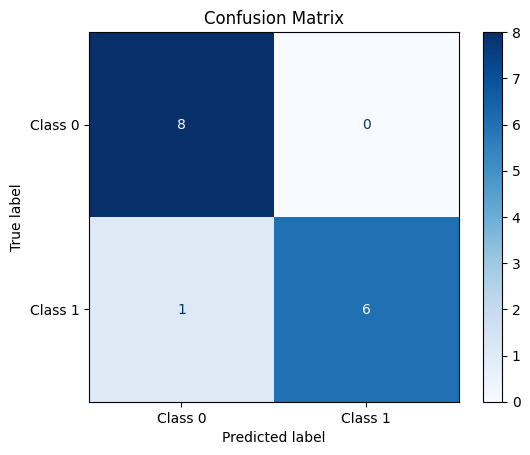

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
